In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
df=sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
features=['pclass','sex','embarked','fare','age']
taregt=['survived']

In [19]:
from sklearn.impute import SimpleImputer
imput_mean=SimpleImputer(strategy='median')
df[['age']]=imput_mean.fit_transform(df[['age']])
impute_most_f=SimpleImputer(strategy='most_frequent')
df[['embarked']]=impute_most_f.fit_transform(df[['embarked']])

In [20]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [21]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['sex']=le.fit_transform(df['sex'])
df['embarked']=le.fit_transform(df['embarked'])

In [22]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [23]:
X=df[features]
Y=df[taregt]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [25]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

print("\nConfusion Matrix:")
print(cm)

Accuracy: 75.98%
Precision: 70.13%
Recall: 72.97%
F1 Score: 71.52%

Confusion Matrix:
[[82 23]
 [20 54]]


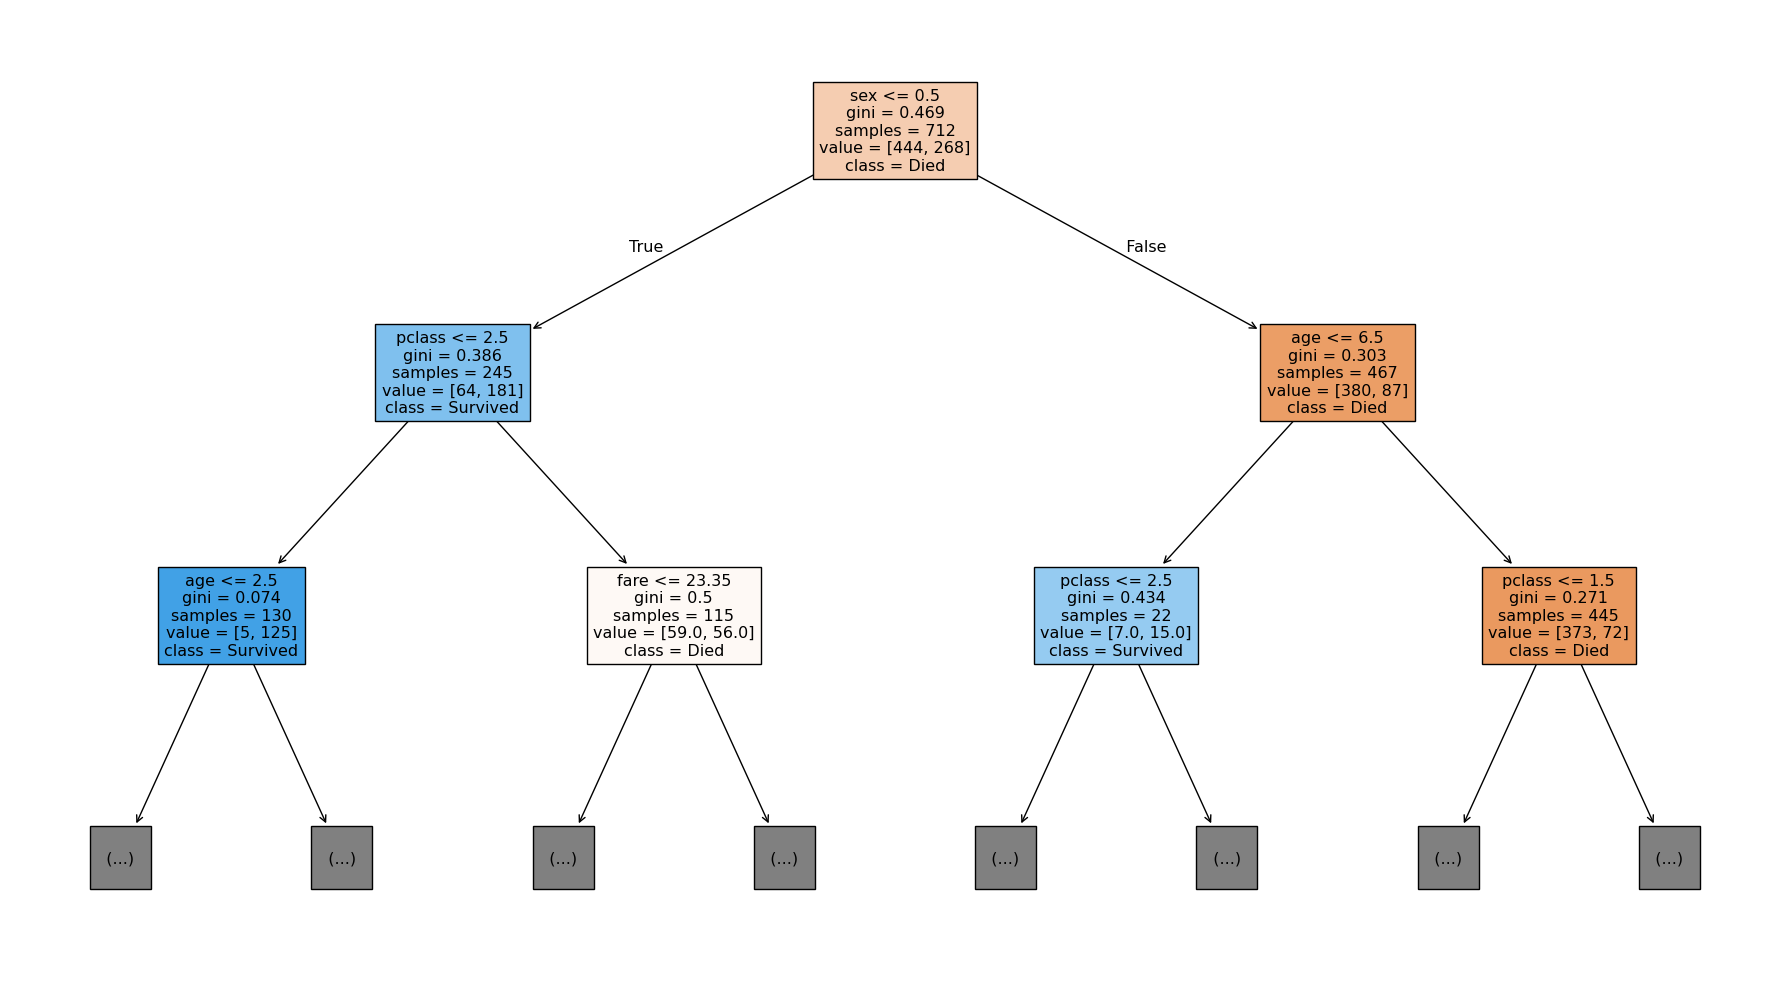

In [27]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Died', 'Survived'],
    filled=True,
    max_depth=2
)

plt.tight_layout()
plt.show()

## Decision Tree with Pre-Pruning

In [33]:
from sklearn.metrics import accuracy_score

for d in range(1, 11):
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print("Depth:", d, "Accuracy:", acc)

Depth: 1 Accuracy: 0.7821229050279329
Depth: 2 Accuracy: 0.7653631284916201
Depth: 3 Accuracy: 0.7988826815642458
Depth: 4 Accuracy: 0.7988826815642458
Depth: 5 Accuracy: 0.7988826815642458
Depth: 6 Accuracy: 0.8044692737430168
Depth: 7 Accuracy: 0.7988826815642458
Depth: 8 Accuracy: 0.7932960893854749
Depth: 9 Accuracy: 0.8044692737430168
Depth: 10 Accuracy: 0.8100558659217877


In [12]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [41]:
model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=7,
    max_leaf_nodes=30,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7988826815642458
